In [ ]:
pip install pyeit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 19.3 MB/s eta 0:00:00
  Created wheel for pyeit: filename=pyeit-1.2.4-py2.py3-none-any.whl size=93838 sha256=9f3c866004b6c19fc1b4cce14f595ef282ec2a56af879e9a9e70832dfee9caf7
  Stored in directory: /root/.cache/pip/wheels/db/b1/9d/416cb6e08ecf87b983abcce9f1c741b627d34876f1913f863a
Successfully built pyeit


Jumlah elemen mesh: 1326
Jumlah injeksi: 16
Jumlah elektroda: 16
Jumlah fitur X: 256
[Tumor] 1/500
[Tumor] 21/500
[Tumor] 41/500
[Tumor] 61/500
[Tumor] 81/500
[Tumor] 101/500
[Tumor] 121/500
[Tumor] 141/500
[Tumor] 161/500
[Tumor] 181/500
[Tumor] 201/500
[Tumor] 221/500
[Tumor] 241/500
[Tumor] 261/500
[Tumor] 281/500
[Tumor] 301/500
[Tumor] 321/500
[Tumor] 341/500
[Tumor] 361/500
[Tumor] 381/500
[Tumor] 401/500
[Tumor] 421/500
[Tumor] 441/500
[Tumor] 461/500
[Tumor] 481/500
[Pneumonia] 1/500
[Pneumonia] 21/500
[Pneumonia] 41/500
[Pneumonia] 61/500
[Pneumonia] 81/500
[Pneumonia] 101/500
[Pneumonia] 121/500
[Pneumonia] 141/500
[Pneumonia] 161/500
[Pneumonia] 181/500
[Pneumonia] 201/500
[Pneumonia] 221/500
[Pneumonia] 241/500
[Pneumonia] 261/500
[Pneumonia] 281/500
[Pneumonia] 301/500
[Pneumonia] 321/500
[Pneumonia] 341/500
[Pneumonia] 361/500
[Pneumonia] 381/500
[Pneumonia] 401/500
[Pneumonia] 421/500
[Pneumonia] 441/500
[Pneumonia] 461/500
[Pneumonia] 481/500
[Effusion] 1/500
[Effusion]

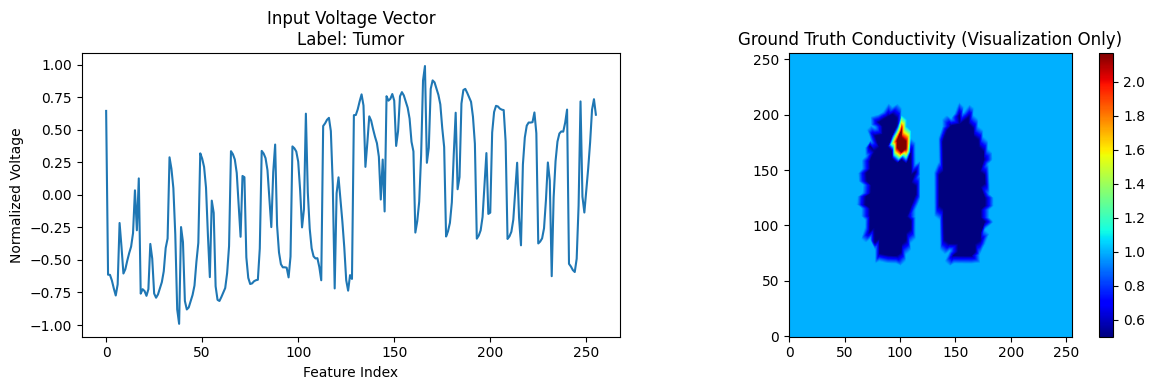

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.interpolate import griddata

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward

# =========================================================
# 1. REPRODUCIBILITY
# =========================================================
np.random.seed(42)

# =========================================================
# 2. MESH THORAX
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]

n_elem = len(tri)
print("Jumlah elemen mesh:", n_elem)

# =========================================================
# 3. DEFINISI PARU
# =========================================================
lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

# =========================================================
# 4. PROTOCOL
# =========================================================
protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

ex_mat = protocol_obj.ex_mat
n_inj = len(ex_mat)
n_el = len(el_pos)

print("Jumlah injeksi:", n_inj)
print("Jumlah elektroda:", n_el)

# =========================================================
# 5. INPUT DIMENSION
# PAPER: 208 boundary voltage values
# Karena setup kamu 16x16, kita flatten:
# (n_inj, n_el) -> vector
# =========================================================
n_features = n_inj * n_el
print("Jumlah fitur X:", n_features)

# =========================================================
# 6. GRID UNTUK VISUALISASI SAJA
# =========================================================
nx_vis, ny_vis = 256, 256
gx_vis = np.linspace(pts[:, 0].min(), pts[:, 0].max(), nx_vis)
gy_vis = np.linspace(pts[:, 1].min(), pts[:, 1].max(), ny_vis)
GX_vis, GY_vis = np.meshgrid(gx_vis, gy_vis)

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

# =========================================================
# 7. PHANTOM FUNCTIONS
# =========================================================
def make_tumor_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.04, 0.09)
    ry = np.random.uniform(0.04, 0.09)
    sigma_tumor = np.random.uniform(2.0, 3.0)

    tumor = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    tumor = tumor & (lung_left if side == "left" else lung_right)

    perm[tumor] = sigma_tumor

    info = {
        "type": "tumor",
        "label": 0,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_tumor
    }
    return perm, info

def make_pneumonia_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.06, 0.12)
    ry = np.random.uniform(0.06, 0.12)
    sigma_lesion = np.random.uniform(1.25, 1.5)

    lesion = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    lesion = lesion & (lung_left if side == "left" else lung_right)

    perm[lesion] = sigma_lesion

    info = {
        "type": "pneumonia",
        "label": 1,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_lesion
    }
    return perm, info

def make_effusion_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        lung_mask = lung_left
        x0 = -0.25
    else:
        lung_mask = lung_right
        x0 = 0.25

    rx = np.random.uniform(0.14, 0.22)
    ry = np.random.uniform(0.10, 0.16)
    tx = x0 + np.random.uniform(-0.03, 0.03)
    ty = np.random.uniform(-0.28, -0.12)

    pocket_outer = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0

    rx_inner = rx * np.random.uniform(0.55, 0.75)
    ry_inner = ry * np.random.uniform(0.55, 0.75)
    tx_inner = tx + np.random.uniform(-0.01, 0.01)
    ty_inner = ty + np.random.uniform(0.03, 0.07)

    pocket_inner = (((cx - tx_inner) / rx_inner) ** 2 + ((cy - ty_inner) / ry_inner) ** 2) <= 1.0

    effusion = pocket_outer & (~pocket_inner)
    effusion = effusion & (cy < 0.02)
    effusion = effusion & (~lung_mask)

    sigma_effusion = 3.5
    perm[effusion] = sigma_effusion

    info = {
        "type": "pleural_effusion",
        "label": 2,
        "side": side,
        "center": (tx, ty),
        "radius_outer": (rx, ry),
        "sigma": sigma_effusion
    }
    return perm, info

# =========================================================
# 8. FORWARD SOLVER -> X VECTOR
# =========================================================
def solve_forward_vector(perm):
    mesh_obj.perm = perm

    try:
        fwd = EITForward(mesh_obj, protocol_obj, z=0.01)
    except Exception:
        fwd = EITForward(mesh_obj, protocol_obj)

    x_sample = np.zeros((n_inj, n_el), dtype=np.float32)

    for j, ex_line in enumerate(ex_mat):
        out = fwd.solve(ex_line)

        if isinstance(out, tuple):
            node_potential = out[0]
        else:
            node_potential = out

        node_potential = np.asarray(node_potential).reshape(-1)
        x_sample[j, :] = node_potential[el_pos].astype(np.float32)

    return x_sample.reshape(-1).astype(np.float32)   # flatten -> (n_features,)

# =========================================================
# 9. GENERATE DATASET 1500
# X: (1500, n_features)
# Y: (1500, n_elem)
# =========================================================
n_tumor = 500
n_pneumonia = 500
n_effusion = 500
n_total = n_tumor + n_pneumonia + n_effusion

X = np.zeros((n_total, n_features), dtype=np.float32)
Y = np.zeros((n_total, n_elem), dtype=np.float32)
labels = np.zeros((n_total,), dtype=np.int32)
info_list = []

idx = 0

for i in range(n_tumor):
    if i % 20 == 0:
        print(f"[Tumor] {i+1}/{n_tumor}")
    perm, info = make_tumor_phantom()
    X[idx] = solve_forward_vector(perm)
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 0
    info_list.append(info)
    idx += 1

for i in range(n_pneumonia):
    if i % 20 == 0:
        print(f"[Pneumonia] {i+1}/{n_pneumonia}")
    perm, info = make_pneumonia_phantom()
    X[idx] = solve_forward_vector(perm)
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 1
    info_list.append(info)
    idx += 1

for i in range(n_effusion):
    if i % 20 == 0:
        print(f"[Effusion] {i+1}/{n_effusion}")
    perm, info = make_effusion_phantom()
    X[idx] = solve_forward_vector(perm)
    Y[idx] = perm.astype(np.float32)
    labels[idx] = 2
    info_list.append(info)
    idx += 1

print("Dataset selesai dibuat.")
print("Shape X:", X.shape)
print("Shape Y:", Y.shape)
print("Shape labels:", labels.shape)

# =========================================================
# 10. SHUFFLE
# =========================================================
perm_idx = np.random.permutation(n_total)
X = X[perm_idx]
Y = Y[perm_idx]
labels = labels[perm_idx]
info_list = [info_list[i] for i in perm_idx]

# =========================================================
# 11. SPLIT TRAIN / VAL / TEST (70/15/15)
# =========================================================
X_train, X_temp, Y_train, Y_temp, labels_train, labels_temp = train_test_split(
    X, Y, labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val, X_test, Y_val, Y_test, labels_val, labels_test = train_test_split(
    X_temp, Y_temp, labels_temp,
    test_size=0.50,
    random_state=42,
    stratify=labels_temp
)

print("\n===== HASIL SPLIT =====")
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

print("Train class:", np.bincount(labels_train))
print("Val class  :", np.bincount(labels_val))
print("Test class :", np.bincount(labels_test))

# =========================================================
# 12. NORMALIZE INPUT X SAJA
# PAPER pakai MSE dan training langsung pada conductivity target
# jadi Y dibiarkan di skala aslinya
# =========================================================
x_mean = X_train.mean(axis=0, keepdims=True)
x_std = X_train.std(axis=0, keepdims=True) + 1e-8

X_train_n = (X_train - x_mean) / x_std
X_val_n   = (X_val   - x_mean) / x_std
X_test_n  = (X_test  - x_mean) / x_std

print("\nInput normalization selesai.")

# =========================================================
# 13. SAVE DATASET
# =========================================================
np.savez_compressed(
    "eit_dataset_paper_style_1500.npz",
    X_train=X_train_n,
    Y_train=Y_train,
    labels_train=labels_train,
    X_val=X_val_n,
    Y_val=Y_val,
    labels_val=labels_val,
    X_test=X_test_n,
    Y_test=Y_test,
    labels_test=labels_test,
    x_mean=x_mean,
    x_std=x_std
)

print("Saved: eit_dataset_paper_style_1500.npz")

# =========================================================
# 14. VISUAL CHECK
# =========================================================
label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

sample_idx = 0
perm_true = Y_train[sample_idx]
img_true = perm_to_grid(perm_true, GX_vis, GY_vis)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(X_train_n[sample_idx])
plt.title(f"Input Voltage Vector\nLabel: {label_names[int(labels_train[sample_idx])]}")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Voltage")

plt.subplot(1, 2, 2)
plt.imshow(img_true, cmap="jet", origin="lower")
plt.title("Ground Truth Conductivity (Visualization Only)")
plt.colorbar()

plt.tight_layout()
plt.show()

X_train: (1050, 256)
Y_train: (1050, 1326)
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.2939 - mae: 0.4059
Epoch 1: val_loss improved from None to 0.03339, saving model to best_model_1.keras

Epoch 1: finished saving model to best_model_1.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.1406 - mae: 0.2519 - val_loss: 0.0334 - val_mae: 0.1073 - learning_rate: 0.0010
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0366 - mae: 0.1150
Epoch 2: val_loss improved from 0.03339 to 0.02857, saving model to best_model_1.keras

Epoch 2: finished saving model to best_model_1.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0348 - mae: 0.1088 - val_loss: 0.0286 - val_mae: 0.0879 - learning_rate: 0.0010
Epoch 3/100
28/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0262 - mae: 0.0872
Epoch 3: val_loss improved from 0.02857 to 0.02529, saving model to best_model_1.keras

Epoch 3: finished saving model to best_model_1.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/s

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

=== INDIVIDUAL MODEL PERFORMANCE (VAL) ===
Model 1 -> RMSE: 0.081370, R2: 0.119773
Model 2 -> RMSE: 0.088369, R2: 0.109064
Model 3 -> RMSE: 0.082534, R2: 0.115549

Best ensemble weights: (np.float64(1.0), np.float64(0.1), np.float64(0.2))
Best validation R2: 0.12009856543732123

=== TEST PERFORMANCE ===
Model 1 -> RMSE: 0.083094, R2: 0.115436
Model 2 -> RMSE: 0.089393, R2: 0.108094
Model 3 -> RMSE: 0.083931, R2: 0.112541
Ensemble -> RMSE: 0.082683, R2: 0.115968

=== ENSEMBLE PER-CASE TEST PERFORMANCE ===
Tumor -> RMSE: 0.095343, R2: 0.053992
Pneumonia -> RMSE: 0.055867, R2: 0.068325
Pleural Effusion -> RMSE: 0.091094, R2: 0.055558


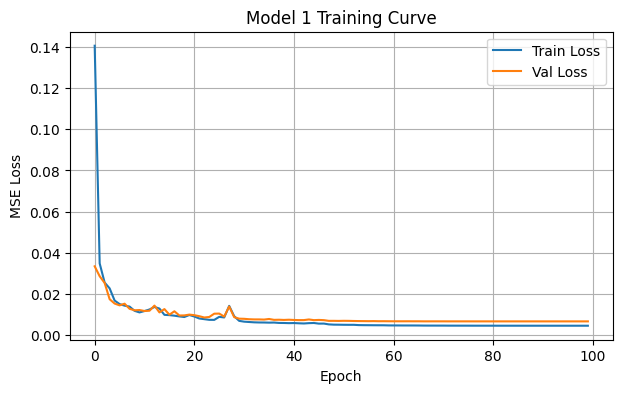

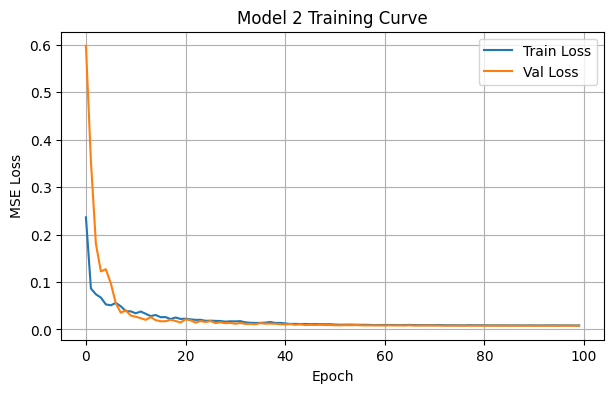

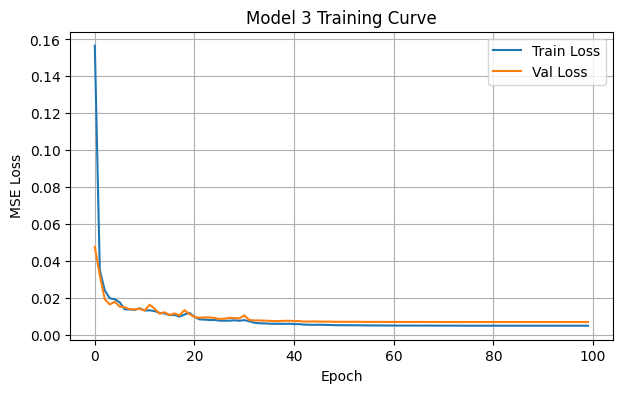

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================================================
# 1. LOAD DATASET
# =========================================================
data = np.load("eit_dataset_paper_style_1500.npz", allow_pickle=True)

X_train = data["X_train"]
Y_train = data["Y_train"]
labels_train = data["labels_train"]

X_val = data["X_val"]
Y_val = data["Y_val"]
labels_val = data["labels_val"]

X_test = data["X_test"]
Y_test = data["Y_test"]
labels_test = data["labels_test"]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

input_dim = X_train.shape[1]
output_dim = Y_train.shape[1]

# =========================================================
# 2. METRICS
# =========================================================
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def evaluate_model(name, y_true, y_pred):
    rmse = compute_rmse(y_true, y_pred)
    r2 = r2_score(y_true, y_pred, multioutput="uniform_average")
    print(f"{name} -> RMSE: {rmse:.6f}, R2: {r2:.6f}")
    return rmse, r2

# =========================================================
# 3. MODEL DEFINITIONS
# =========================================================
def build_model_1():
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation="relu")(inputs)
    x = layers.Dense(1024, activation="relu")(x)
    x = layers.Dense(2048, activation="relu")(x)
    outputs = layers.Dense(output_dim, activation="linear")(x)
    return Model(inputs, outputs, name="model_1_simple")

def build_model_2():
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1024, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(2048, activation="relu")(x)
    outputs = layers.Dense(output_dim, activation="linear")(x)
    return Model(inputs, outputs, name="model_2_bn_dropout")

def build_model_3():
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(1024, activation="relu")(inputs)
    x1 = layers.Dense(1024, activation="relu")(x)
    x2 = layers.Dense(1024, activation="relu")(x1)
    x = layers.Add()([x1, x2])  # residual-like
    x = layers.Dense(2048, activation="relu")(x)
    outputs = layers.Dense(output_dim, activation="linear")(x)
    return Model(inputs, outputs, name="model_3_residual_like")

# =========================================================
# 4. TRAIN FUNCTION
# =========================================================
def train_one_model(model, save_name, epochs=100, batch_size=32):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            save_name,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history

# =========================================================
# 5. TRAIN MODELS
# =========================================================
model1 = build_model_1()
history1 = train_one_model(model1, "best_model_1.keras")

model2 = build_model_2()
history2 = train_one_model(model2, "best_model_2.keras")

model3 = build_model_3()
history3 = train_one_model(model3, "best_model_3.keras")

# =========================================================
# 6. PREDICT EACH MODEL
# =========================================================
pred1_val = model1.predict(X_val, batch_size=32)
pred2_val = model2.predict(X_val, batch_size=32)
pred3_val = model3.predict(X_val, batch_size=32)

pred1_test = model1.predict(X_test, batch_size=32)
pred2_test = model2.predict(X_test, batch_size=32)
pred3_test = model3.predict(X_test, batch_size=32)

print("\n=== INDIVIDUAL MODEL PERFORMANCE (VAL) ===")
evaluate_model("Model 1", Y_val, pred1_val)
evaluate_model("Model 2", Y_val, pred2_val)
evaluate_model("Model 3", Y_val, pred3_val)

# =========================================================
# 7. WEIGHTED ENSEMBLE SEARCH
# mirip paper: cari kombinasi bobot terbaik
# =========================================================
best_r2 = -np.inf
best_weights = None
best_pred_val = None

weight_candidates = np.arange(0.0, 1.01, 0.1)

for w1 in weight_candidates:
    for w2 in weight_candidates:
        for w3 in weight_candidates:
            s = w1 + w2 + w3
            if s == 0:
                continue

            pred_val = (w1 * pred1_val + w2 * pred2_val + w3 * pred3_val) / s
            r2 = r2_score(Y_val, pred_val, multioutput="uniform_average")

            if r2 > best_r2:
                best_r2 = r2
                best_weights = (w1, w2, w3)
                best_pred_val = pred_val.copy()

print("\nBest ensemble weights:", best_weights)
print("Best validation R2:", best_r2)

# =========================================================
# 8. APPLY BEST ENSEMBLE TO TEST
# =========================================================
w1, w2, w3 = best_weights
s = w1 + w2 + w3

pred_ens_test = (w1 * pred1_test + w2 * pred2_test + w3 * pred3_test) / s

print("\n=== TEST PERFORMANCE ===")
evaluate_model("Model 1", Y_test, pred1_test)
evaluate_model("Model 2", Y_test, pred2_test)
evaluate_model("Model 3", Y_test, pred3_test)
evaluate_model("Ensemble", Y_test, pred_ens_test)

# =========================================================
# 9. PER-CASE EVALUATION
# =========================================================
label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

print("\n=== ENSEMBLE PER-CASE TEST PERFORMANCE ===")
for label in [0, 1, 2]:
    idx = np.where(labels_test == label)[0]
    y_true_case = Y_test[idx]
    y_pred_case = pred_ens_test[idx]
    evaluate_model(label_names[label], y_true_case, y_pred_case)

# =========================================================
# 10. PLOT TRAINING CURVES
# =========================================================
def plot_history(history, title):
    plt.figure(figsize=(7,4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history1, "Model 1 Training Curve")
plot_history(history2, "Model 2 Training Curve")
plot_history(history3, "Model 3 Training Curve")

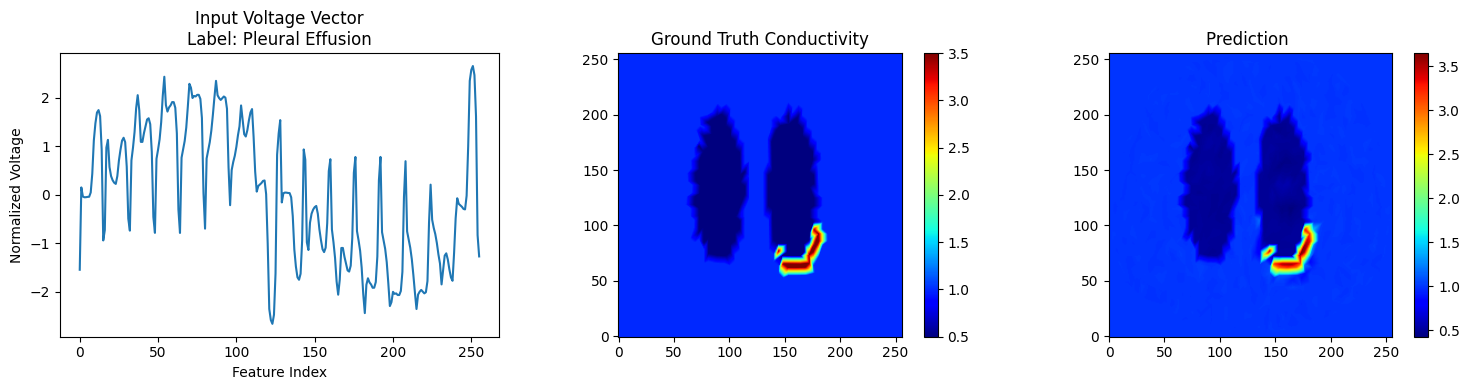

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================================================
# NOTE:
# pastikan variabel berikut masih ada:
# - centers
# - GX_vis, GY_vis
# - X_test
# - Y_test
# - labels_test
# - pred_ens_test
# =========================================================

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

sample_idx = 2

true_perm = Y_test[sample_idx]
pred_perm = pred_ens_test[sample_idx]

true_img = perm_to_grid(true_perm, GX_vis, GY_vis)
pred_img = perm_to_grid(pred_perm, GX_vis, GY_vis)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(X_test[sample_idx])
plt.title(f"Input Voltage Vector\nLabel: {label_names[int(labels_test[sample_idx])]}")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Voltage")

plt.subplot(1, 3, 2)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth Conductivity")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction ")
#plt.title("Prediction - Ensemble")

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================================================
# NOTE:
# pastikan variabel berikut masih ada:
# - centers
# - GX_vis, GY_vis
# - X_test
# - Y_test
# - labels_test
# - pred_ens_test
# =========================================================

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

sample_idx = 2

true_perm = Y_test[sample_idx]
pred_perm = pred_ens_test[sample_idx]

true_img = perm_to_grid(true_perm, GX_vis, GY_vis)
pred_img = perm_to_grid(pred_perm, GX_vis, GY_vis)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(X_test[sample_idx])
plt.title(f"Input Voltage Vector\nLabel: {label_names[int(labels_test[sample_idx])]}")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Voltage")

plt.subplot(1, 3, 2)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth Conductivity")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction ")
#plt.title("Prediction - Ensemble")

plt.colorbar()

plt.tight_layout()
plt.show()

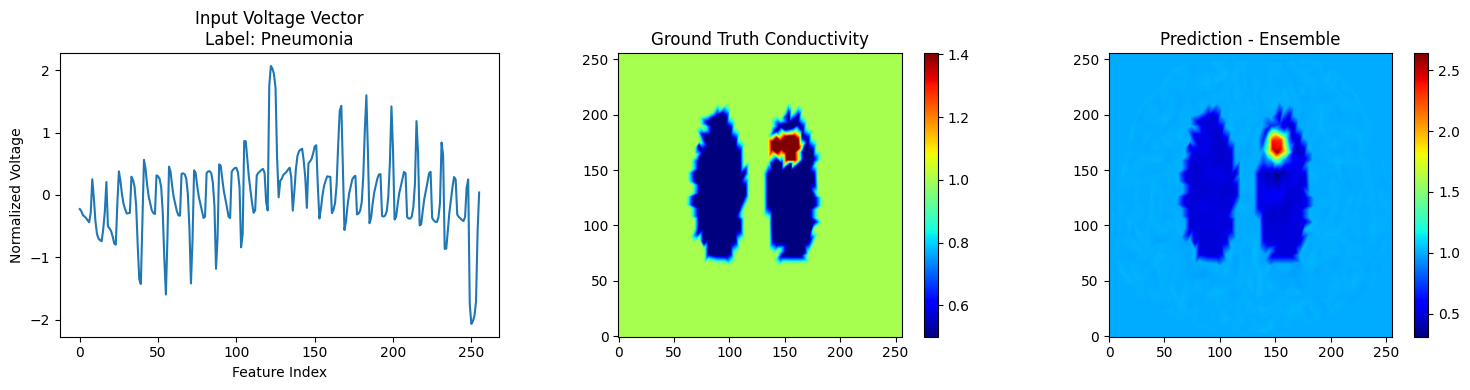

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =========================================================
# NOTE:
# pastikan variabel berikut masih ada:
# - centers
# - GX_vis, GY_vis
# - X_test
# - Y_test
# - labels_test
# - pred_ens_test
# =========================================================

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

sample_idx = 4

true_perm = Y_test[sample_idx]
pred_perm = pred_ens_test[sample_idx]

true_img = perm_to_grid(true_perm, GX_vis, GY_vis)
pred_img = perm_to_grid(pred_perm, GX_vis, GY_vis)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(X_test[sample_idx])
plt.title(f"Input Voltage Vector\nLabel: {label_names[int(labels_test[sample_idx])]}")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Voltage")

plt.subplot(1, 3, 2)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth Conductivity")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction - Ensemble")
plt.colorbar()

plt.tight_layout()
plt.show()

Original index: 1
Posisi setelah shuffle: 1308
Masuk TRAIN set
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


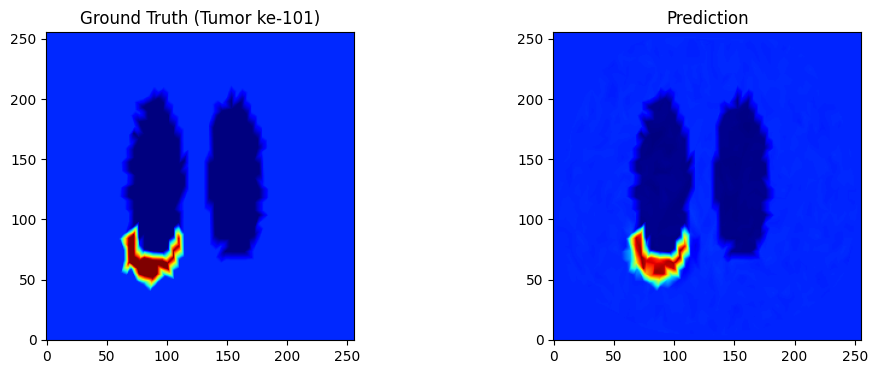

In [ ]:
# =========================================================
# 🔥 AMBIL: tumor ke-101 sebelum shuffle
# TANPA UBAH PIPELINE
# =========================================================

import numpy as np

# -------------------------------
# 1. RECREATE SHUFFLE
# -------------------------------
np.random.seed(42)
n_total = 1500  # 500 + 500 + 500

perm_idx = np.random.permutation(n_total)

# tumor ke-101 sebelum shuffle
target_original_index = 1

# cari posisi setelah shuffle
shuffled_index = np.where(perm_idx == target_original_index)[0][0]

print("Original index:", target_original_index)
print("Posisi setelah shuffle:", shuffled_index)

# -------------------------------
# 2. RECREATE SPLIT INDEX
# -------------------------------
from sklearn.model_selection import train_test_split

indices = np.arange(n_total)

idx_train, idx_temp = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels  # pakai labels yg sudah di-load
)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=0.50,
    random_state=42,
    stratify=labels[idx_temp]
)

# -------------------------------
# 3. CARI DIA ADA DI MANA
# -------------------------------
if shuffled_index in idx_test:
    pos = np.where(idx_test == shuffled_index)[0][0]
    x_sample = X_test[pos].reshape(1,-1)
    y_true = Y_test[pos]
    print("Masuk TEST set")

elif shuffled_index in idx_val:
    pos = np.where(idx_val == shuffled_index)[0][0]
    x_sample = X_val[pos].reshape(1,-1)
    y_true = Y_val[pos]
    print("Masuk VAL set")

else:
    pos = np.where(idx_train == shuffled_index)[0][0]
    x_sample = X_train[pos].reshape(1,-1)
    y_true = Y_train[pos]
    print("Masuk TRAIN set")

# -------------------------------
# 4. PREDIKSI ENSEMBLE
# -------------------------------
y_pred = (w1 * model1.predict(x_sample) +
          w2 * model2.predict(x_sample) +
          w3 * model3.predict(x_sample)) / (w1 + w2 + w3)

y_pred = y_pred.reshape(-1)

# -------------------------------
# 5. VISUALISASI
# -------------------------------
true_img = perm_to_grid(y_true, GX_vis, GY_vis)
pred_img = perm_to_grid(y_pred, GX_vis, GY_vis)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth (Tumor ke-101)")

plt.subplot(1,2,2)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction")

plt.show()


In [ ]:
# =========================================================
# 🔥 LOAD DATASET SAMPAI SEBELUM SHUFFLE
# =========================================================

# JALANKAN SEMUA CELL DARI AWAL SAMPAI:
# (SEBELUM BAGIAN INI)
# =========================================================
# 10. SHUFFLE
# =========================================================

# LALU TAMBAHKAN:

X_raw = X.copy()
Y_raw = Y.copy()
labels_raw = labels.copy()

print("RAW dataset saved in memory")


RAW dataset saved in memory


Index: 1300
Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


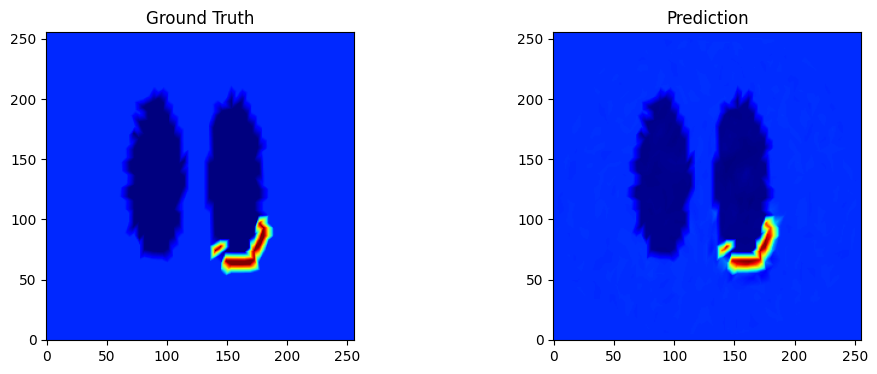

In [ ]:
class_id = 2
n = 300

index = class_id * 500 + n

x_sample = X_raw[index].reshape(1, -1)
y_true = Y_raw[index]

print("Index:", index)
print("Label:", labels_raw[index])
x_sample = (x_sample - x_mean) / x_std
y_pred = (w1 * model1.predict(x_sample) +
          w2 * model2.predict(x_sample) +
          w3 * model3.predict(x_sample)) / (w1 + w2 + w3)

y_pred = y_pred.reshape(-1)
true_img = perm_to_grid(y_true, GX_vis, GY_vis)
pred_img = perm_to_grid(y_pred, GX_vis, GY_vis)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction")

plt.show()


Index: 50
Label: 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


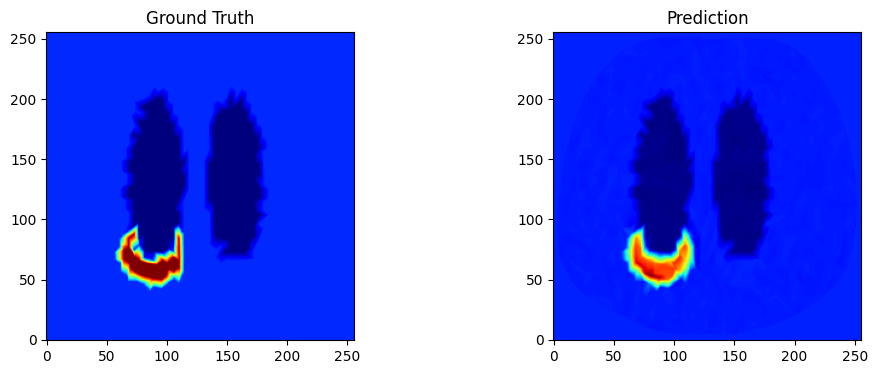

In [ ]:
class_id = 0
n = 50

index = class_id * 500 + n

x_sample = X_raw[index].reshape(1, -1)
y_true = Y_raw[index]

print("Index:", index)
print("Label:", labels_raw[index])
x_sample = (x_sample - x_mean) / x_std
y_pred = (w1 * model1.predict(x_sample) +
          w2 * model2.predict(x_sample) +
          w3 * model3.predict(x_sample)) / (w1 + w2 + w3)

y_pred = y_pred.reshape(-1)
true_img = perm_to_grid(y_true, GX_vis, GY_vis)
pred_img = perm_to_grid(y_pred, GX_vis, GY_vis)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth")

plt.subplot(1,2,2)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction")

plt.show()


# ALL PLOT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.interpolate import griddata

import pyeit.mesh as mesh
from pyeit.eit.protocol import create as protocol_create
from pyeit.eit.fem import EITForward

# =========================================================
# 1. REPRODUCIBILITY
# =========================================================
np.random.seed(42)

# =========================================================
# 2. MESH THORAX
# =========================================================
mesh_obj = mesh.create(
    n_el=16,
    h0=0.06,
    fd=mesh.shape.thorax
)

pts = mesh_obj.node[:, :2]
tri = mesh_obj.element
el_pos = mesh_obj.el_pos

if hasattr(mesh_obj, "elem_centers"):
    centers = mesh_obj.elem_centers[:, :2]
else:
    centers = pts[tri].mean(axis=1)

cx = centers[:, 0]
cy = centers[:, 1]

n_elem = len(tri)
print("Jumlah elemen mesh:", n_elem)

# =========================================================
# 3. DEFINISI PARU
# =========================================================
lung_left = (((cx + 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0
lung_right = (((cx - 0.25) / 0.18) ** 2 + ((cy - 0.05) / 0.35) ** 2) <= 1.0

# =========================================================
# 4. PROTOCOL
# =========================================================
protocol_obj = protocol_create(
    n_el=16,
    dist_exc=8,
    step_meas=1,
    parser_meas="std"
)

ex_mat = protocol_obj.ex_mat
n_inj = len(ex_mat)
n_el = len(el_pos)

print("Jumlah injeksi:", n_inj)
print("Jumlah elektroda:", n_el)

# =========================================================
# 5. INPUT DIMENSION
# PAPER: 208 boundary voltage values
# Karena setup kamu 16x16, kita flatten:
# (n_inj, n_el) -> vector
# =========================================================
n_features = n_inj * n_el
print("Jumlah fitur X:", n_features)

# =========================================================
# 6. GRID UNTUK VISUALISASI SAJA
# =========================================================
nx_vis, ny_vis = 256, 256
gx_vis = np.linspace(pts[:, 0].min(), pts[:, 0].max(), nx_vis)
gy_vis = np.linspace(pts[:, 1].min(), pts[:, 1].max(), ny_vis)
GX_vis, GY_vis = np.meshgrid(gx_vis, gy_vis)

def perm_to_grid(perm, GX, GY):
    img = griddata(
        points=centers,
        values=perm,
        xi=(GX, GY),
        method="linear"
    )
    img = np.where(np.isnan(img), 1.0, img)
    return img

# =========================================================
# 7. PHANTOM FUNCTIONS
# =========================================================
def make_tumor_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.04, 0.09)
    ry = np.random.uniform(0.04, 0.09)
    sigma_tumor = np.random.uniform(2.0, 3.0)

    tumor = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    tumor = tumor & (lung_left if side == "left" else lung_right)

    perm[tumor] = sigma_tumor

    info = {
        "type": "tumor",
        "label": 0,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_tumor
    }
    return perm, info

def make_pneumonia_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        tx = np.random.uniform(-0.32, -0.15)
        ty = np.random.uniform(-0.05, 0.28)
    else:
        tx = np.random.uniform(0.15, 0.32)
        ty = np.random.uniform(-0.05, 0.28)

    rx = np.random.uniform(0.06, 0.12)
    ry = np.random.uniform(0.06, 0.12)
    sigma_lesion = np.random.uniform(1.25, 1.5)

    lesion = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0
    lesion = lesion & (lung_left if side == "left" else lung_right)

    perm[lesion] = sigma_lesion

    info = {
        "type": "pneumonia",
        "label": 1,
        "side": side,
        "center": (tx, ty),
        "radius": (rx, ry),
        "sigma": sigma_lesion
    }
    return perm, info

def make_effusion_phantom():
    perm = np.ones(n_elem, dtype=float)
    perm[lung_left] = 0.5
    perm[lung_right] = 0.5

    side = np.random.choice(["left", "right"])

    if side == "left":
        lung_mask = lung_left
        x0 = -0.25
    else:
        lung_mask = lung_right
        x0 = 0.25

    rx = np.random.uniform(0.14, 0.22)
    ry = np.random.uniform(0.10, 0.16)
    tx = x0 + np.random.uniform(-0.03, 0.03)
    ty = np.random.uniform(-0.28, -0.12)

    pocket_outer = (((cx - tx) / rx) ** 2 + ((cy - ty) / ry) ** 2) <= 1.0

    rx_inner = rx * np.random.uniform(0.55, 0.75)
    ry_inner = ry * np.random.uniform(0.55, 0.75)
    tx_inner = tx + np.random.uniform(-0.01, 0.01)
    ty_inner = ty + np.random.uniform(0.03, 0.07)

    pocket_inner = (((cx - tx_inner) / rx_inner) ** 2 + ((cy - ty_inner) / ry_inner) ** 2) <= 1.0

    effusion = pocket_outer & (~pocket_inner)
    effusion = effusion & (cy < 0.02)
    effusion = effusion & (~lung_mask)

    sigma_effusion = 3.5
    perm[effusion] = sigma_effusion

    info = {
        "type": "pleural_effusion",
        "label": 2,
        "side": side,
        "center": (tx, ty),
        "radius_outer": (rx, ry),
        "sigma": sigma_effusion
    }
    return perm, info

# =========================================================
# 8. FORWARD SOLVER -> X VECTOR
# =========================================================
def solve_forward_vector(perm):
    mesh_obj.perm = perm

    try:
        fwd = EITForward(mesh_obj, protocol_obj, z=0.01)
    except Exception:
        fwd = EITForward(mesh_obj, protocol_obj)

    x_sample = np.zeros((n_inj, n_el), dtype=np.float32)

    for j, ex_line in enumerate(ex_mat):
        out = fwd.solve(ex_line)

        if isinstance(out, tuple):
            node_potential = out[0]
        else:
            node_potential = out

        node_potential = np.asarray(node_potential).reshape(-1)
        x_sample[j, :] = node_potential[el_pos].astype(np.float32)

    return x_sample.reshape(-1).astype(np.float32)   # flatten -> (n_features,)

Jumlah elemen mesh: 1326
Jumlah injeksi: 16
Jumlah elektroda: 16
Jumlah fitur X: 256


In [ ]:
# =========================================================
# 🔥 GENERATE & SAVE RAW DATASET (NO SHUFFLE, NO SPLIT)
# =========================================================

import numpy as np

np.random.seed(42)

n_tumor = 500
n_pneumonia = 500
n_effusion = 500
n_total = n_tumor + n_pneumonia + n_effusion

X_raw = np.zeros((n_total, n_features), dtype=np.float32)
Y_raw = np.zeros((n_total, n_elem), dtype=np.float32)
labels_raw = np.zeros((n_total,), dtype=np.int32)
info_list = []

idx = 0

# -------------------------------
# TUMOR (0–499)
# -------------------------------
for i in range(n_tumor):
    if i % 50 == 0:
        print(f"[Tumor] {i+1}/{n_tumor}")
    perm, info = make_tumor_phantom()
    X_raw[idx] = solve_forward_vector(perm)
    Y_raw[idx] = perm.astype(np.float32)
    labels_raw[idx] = 0
    info_list.append(info)
    idx += 1

# -------------------------------
# PNEUMONIA (500–999)
# -------------------------------
for i in range(n_pneumonia):
    if i % 50 == 0:
        print(f"[Pneumonia] {i+1}/{n_pneumonia}")
    perm, info = make_pneumonia_phantom()
    X_raw[idx] = solve_forward_vector(perm)
    Y_raw[idx] = perm.astype(np.float32)
    labels_raw[idx] = 1
    info_list.append(info)
    idx += 1

# -------------------------------
# EFFUSION (1000–1499)
# -------------------------------
for i in range(n_effusion):
    if i % 50 == 0:
        print(f"[Effusion] {i+1}/{n_effusion}")
    perm, info = make_effusion_phantom()
    X_raw[idx] = solve_forward_vector(perm)
    Y_raw[idx] = perm.astype(np.float32)
    labels_raw[idx] = 2
    info_list.append(info)
    idx += 1

print("\nRAW dataset selesai dibuat!")
print("Shape X_raw:", X_raw.shape)
print("Shape Y_raw:", Y_raw.shape)
print("Shape labels_raw:", labels_raw.shape)

# =========================================================
# 🔥 SAVE RAW DATASET
# =========================================================
np.savez_compressed(
    "eit_dataset_raw_1500.npz",
    X_raw=X_raw,
    Y_raw=Y_raw,
    labels_raw=labels_raw,
    info_list=info_list
)

print("Saved: eit_dataset_raw_1500.npz")


[Tumor] 1/500
[Tumor] 51/500
[Tumor] 101/500
[Tumor] 151/500
[Tumor] 201/500
[Tumor] 251/500
[Tumor] 301/500
[Tumor] 351/500
[Tumor] 401/500
[Tumor] 451/500
[Pneumonia] 1/500
[Pneumonia] 51/500
[Pneumonia] 101/500
[Pneumonia] 151/500
[Pneumonia] 201/500
[Pneumonia] 251/500
[Pneumonia] 301/500
[Pneumonia] 351/500
[Pneumonia] 401/500
[Pneumonia] 451/500
[Effusion] 1/500
[Effusion] 51/500
[Effusion] 101/500
[Effusion] 151/500
[Effusion] 201/500
[Effusion] 251/500
[Effusion] 301/500
[Effusion] 351/500
[Effusion] 401/500
[Effusion] 451/500

RAW dataset selesai dibuat!
Shape X_raw: (1500, 256)
Shape Y_raw: (1500, 1326)
Shape labels_raw: (1500,)
Saved: eit_dataset_raw_1500.npz


Class : Pneumonia
Index : 513
Label : 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


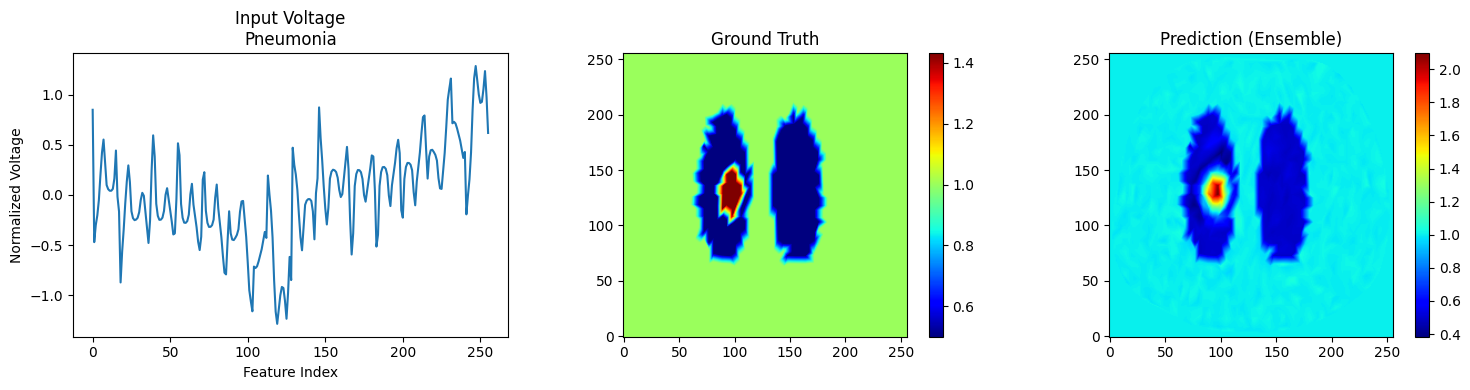

In [ ]:


# =========================================================
# 🔥 PLOT RAW DATA + PREDICTION
# =========================================================

import matplotlib.pyplot as plt

label_names = {0: "Tumor", 1: "Pneumonia", 2: "Pleural Effusion"}

# -------------------------------
# PILIH DATA
# -------------------------------
class_id = 1   # 0=tumor, 1=pneumonia, 2=effusion
n = 13        # data ke-(n+1)

index = class_id * 500 + n

print("===================================")
print("Class :", label_names[class_id])
print("Index :", index)
print("Label :", labels_raw[index])
print("===================================")

# -------------------------------
# AMBIL DATA
# -------------------------------
x_sample = X_raw[index].reshape(1, -1)
y_true = Y_raw[index]


# -------------------------------
# NORMALISASI (WAJIB)
# -------------------------------
x_sample_n = (x_sample - x_mean) / x_std

# -------------------------------
# PREDIKSI ENSEMBLE
# -------------------------------
y_pred = (w1 * model1.predict(x_sample_n) +
          w2 * model2.predict(x_sample_n) +
          w3 * model3.predict(x_sample_n)) / (w1 + w2 + w3)

y_pred = y_pred.reshape(-1)

# -------------------------------
# KONVERSI KE GRID (BIAR JADI IMAGE)
# -------------------------------
true_img = perm_to_grid(y_true, GX_vis, GY_vis)
pred_img = perm_to_grid(y_pred, GX_vis, GY_vis)

# -------------------------------
# PLOT
# -------------------------------
plt.figure(figsize=(15,4))

# Input voltage
plt.subplot(1,3,1)
plt.plot(x_sample_n.flatten())
plt.title(f"Input Voltage\n{label_names[class_id]}")
plt.xlabel("Feature Index")
plt.ylabel("Normalized Voltage")

# Ground truth
plt.subplot(1,3,2)
plt.imshow(true_img, cmap="jet", origin="lower")
plt.title("Ground Truth")
plt.colorbar()

# Prediction
plt.subplot(1,3,3)
plt.imshow(pred_img, cmap="jet", origin="lower")
plt.title("Prediction (Ensemble)")
plt.colorbar()

plt.tight_layout()
plt.show()


In [ ]:
"""0–499   → tumor
500–999 → pneumonia
1000–1499 → effusion"""

start = 0
end   = 500
# Ambil data tumor
X_tumor = X_raw[start:end]

# Normalisasi
X_tumor_n = (X_tumor - x_mean) / x_std

# Prediksi ensemble
Y_pred_tumor = (
    w1 * model1.predict(X_tumor_n) +
    w2 * model2.predict(X_tumor_n) +
    w3 * model3.predict(X_tumor_n)
) / (w1 + w2 + w3)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


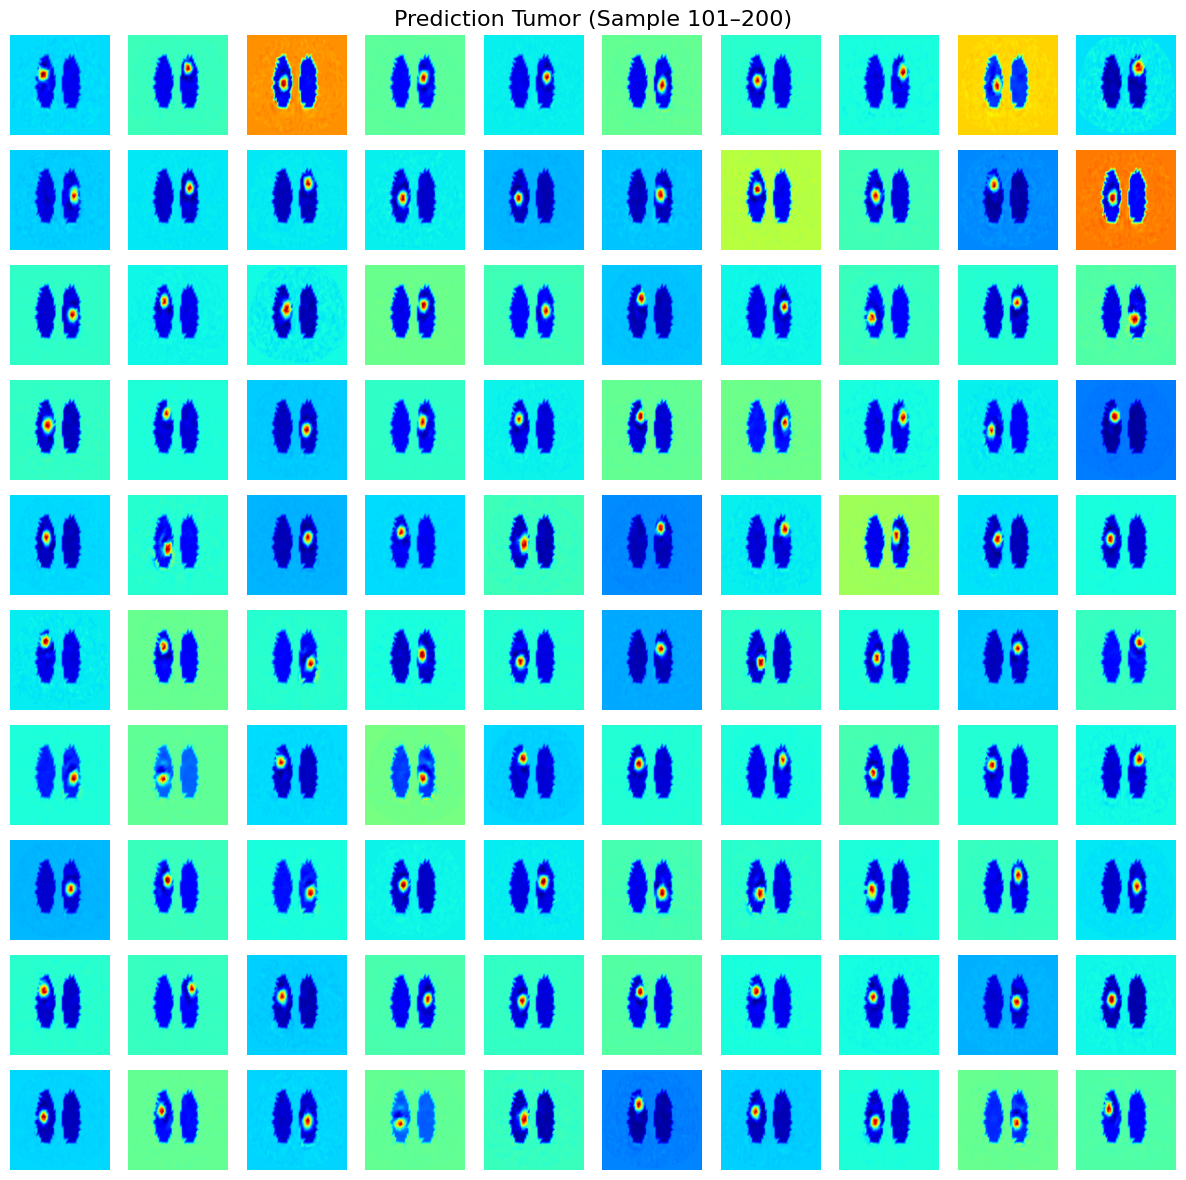

In [ ]:
start = 500
end   = 600

X_tumor = X_raw[start:end]

X_tumor_n = (X_tumor - x_mean) / x_std

Y_pred_tumor = (
    w1 * model1.predict(X_tumor_n) +
    w2 * model2.predict(X_tumor_n) +
    w3 * model3.predict(X_tumor_n)
) / (w1 + w2 + w3)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for i in range(100):
    pred_img = perm_to_grid(Y_pred_tumor[i], GX_vis, GY_vis)

    plt.subplot(10, 10, i+1)
    plt.imshow(pred_img, cmap="jet", origin="lower")
    plt.axis("off")

plt.suptitle("Prediction Tumor (Sample 101–200)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
start = 998
end   = 999

X_tumor = X_raw[start:end]

X_tumor_n = (X_tumor - x_mean) / x_std

Y_pred_tumor = (
    w1 * model1.predict(X_tumor_n) +
    w2 * model2.predict(X_tumor_n) +
    w3 * model3.predict(X_tumor_n)
) / (w1 + w2 + w3)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for i in range(100):
    pred_img = perm_to_grid(Y_pred_tumor[i], GX_vis, GY_vis)

    plt.subplot(10, 10, i+1)
    plt.imshow(pred_img, cmap="jet", origin="lower")
    plt.axis("off")

plt.suptitle("Prediction Tumor (Sample 101–200)", fontsize=16)
plt.tight_layout()
plt.show()